In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('/content/continuous dataset.csv')

In [3]:
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0.0,0.0,0.0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0.0,0.0,0.0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0.0,0.0,0.0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0.0,0.0,0.0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0.0,0.0,0.0


In [4]:
df.tail()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
19209,2017-03-13 10:00:00,1491.4668,29.660669,0.017062,0.055771,21.423704,32.957544,0.014968,0.028656,12.982800,29.457544,0.013427,0.018753,3.574664,0.0,0.0,1.0
19210,2017-03-13 11:00:00,1534.1051,30.309229,0.017016,0.081970,21.118342,34.590479,0.014747,0.021347,11.911216,31.059229,0.013533,0.020241,1.705347,0.0,0.0,1.0
19211,2017-03-13 12:00:00,1538.3853,30.636469,0.017009,0.111694,20.630368,35.698969,0.014567,0.020218,11.050897,32.230219,0.013324,0.027229,0.701181,0.0,0.0,1.0
19212,2017-03-13 13:00:00,1585.5297,30.681970,0.016948,0.127930,19.925646,36.197595,0.014350,0.040680,10.503045,32.900720,0.013057,0.041840,0.271314,0.0,0.0,1.0
19213,2017-03-13 14:00:00,1583.3973,30.539301,0.016803,0.126038,19.265557,36.086176,0.014128,0.089111,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(19214, 17)

In [6]:


# 1.  convert the 'datetime' column to an actual Pandas datetime object
df["datetime"] = pd.to_datetime(df["datetime"])

# Set datetime as the index (crucial for time-series forecasting)
df.set_index('datetime', inplace=True)

# 2. Check for and handle missing values (Interpolation method from the paper)
print("Missing values before cleaning:\n", df.isnull().sum())
df = df.interpolate(method='linear')

# 3. Feature Engineering: Datetime Features
# The paper explicitly states to extract hour, day, and month
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

# 4. Feature Engineering: Lag and Rolling Features
# 'lag_1' is what the demand was exactly 1 hour ago
df['lag_1'] = df['nat_demand'].shift(1)

# 'rolling_mean_24' is the average demand over the last 24 hours
df['rolling_mean_24'] = df['nat_demand'].rolling(window=24).mean()

# Drop the first 24 rows because rolling_mean_24 will be NaN for them
df.dropna(inplace=True)

print("\nNew dataset shape after feature engineering:", df.shape)
print("\nSnapshot of new features:")
print(df[['nat_demand', 'hour', 'lag_1', 'rolling_mean_24']].head())

Missing values before cleaning:
 nat_demand    0
T2M_toc       0
QV2M_toc      0
TQL_toc       0
W2M_toc       0
T2M_san       0
QV2M_san      0
TQL_san       0
W2M_san       0
T2M_dav       1
QV2M_dav      1
TQL_dav       1
W2M_dav       1
Holiday_ID    1
holiday       1
school        1
dtype: int64

New dataset shape after feature engineering: (19191, 21)

Snapshot of new features:
                     nat_demand  hour     lag_1  rolling_mean_24
datetime                                                        
2015-01-04 00:00:00    968.0526     0  999.6340      1065.049338
2015-01-04 01:00:00    944.0556     1  968.0526      1063.953946
2015-01-04 02:00:00    928.7193     2  944.0556      1064.643271
2015-01-04 03:00:00    909.5566     3  928.7193      1065.030263
2015-01-04 04:00:00    894.6543     4  909.5566      1065.226117


In [7]:

from sklearn.preprocessing import MinMaxScaler

# 1. Separating Features (X) and Target (y)
# Dropping the target from X
X = df.drop(columns=['nat_demand'])
y = df['nat_demand'].values.reshape(-1, 1)

# 2. Chronological Train-Test Split (80% Train, 20% Test)

train_size = int(len(df) * 0.8)

X_train_raw, X_test_raw = X.iloc[:train_size], X.iloc[train_size:]
y_train_raw, y_test_raw = y[:train_size], y[train_size:]

# 3. Data Normalization (Min-Max Scaling)

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train = scaler_X.fit_transform(X_train_raw)
X_test = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_test = scaler_y.transform(y_test_raw)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print("Data normalization complete. Scaled between 0 and 1.")

Training features shape: (15352, 20)
Testing features shape: (3839, 20)
Data normalization complete. Scaled between 0 and 1.


In [8]:
df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,TQL_dav,W2M_dav,Holiday_ID,holiday,school,hour,dayofweek,month,lag_1,rolling_mean_24
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-04 00:00:00,968.0526,25.769189,0.018555,0.003251,19.700352,23.823877,0.017655,0.008984,8.157670,22.730127,...,0.091888,4.209796,0.0,0.0,0.0,0,6,1,999.6340,1065.049338
2015-01-04 01:00:00,944.0556,25.681818,0.018494,0.003898,19.893350,23.627130,0.017540,0.006481,8.287433,22.533380,...,0.085571,4.433089,0.0,0.0,0.0,1,6,1,968.0526,1063.953946
2015-01-04 02:00:00,928.7193,25.602319,0.018486,0.004625,19.863871,23.477319,0.017448,0.003056,8.476267,22.360132,...,0.084808,4.673439,0.0,0.0,0.0,2,6,1,944.0556,1064.643271
2015-01-04 03:00:00,909.5566,25.572656,0.018448,0.008533,20.362023,23.369531,0.017387,0.001542,8.692403,22.244531,...,0.082916,4.924833,0.0,0.0,0.0,3,6,1,928.7193,1065.030263
2015-01-04 04:00:00,894.6543,25.547144,0.018409,0.008694,20.651574,23.281519,0.017326,0.001173,8.831439,22.148706,...,0.084351,5.111986,0.0,0.0,0.0,4,6,1,909.5566,1065.226117


In [9]:
time_steps = 24

# Function to create 3D sequences for the LSTM
def create_sequences(X, y, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:(i + time_steps)])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# Reshaping the training and testing data
X_train_3d, y_train_seq = create_sequences(X_train, y_train, time_steps)
X_test_3d, y_test_seq = create_sequences(X_test, y_test, time_steps)

print(f"Final 3D Training shape: {X_train_3d.shape}")
print(f"Final 3D Testing shape: {X_test_3d.shape}")

Final 3D Training shape: (15328, 24, 20)
Final 3D Testing shape: (3815, 24, 20)


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Define the LSTM Architecture
model_lstm = Sequential()

# First LSTM Layer: Reads the 24-hour sequence.
# return_sequences=True means it passes a sequence to the next layer, not just a single number
model_lstm.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])))
model_lstm.add(Dropout(0.2)) # Drops 20% of neurons randomly to prevent the model from memorizing the data (overfitting)

# Second LSTM Layer: Condenses the sequence into final features
model_lstm.add(LSTM(units=32, return_sequences=False))
model_lstm.add(Dropout(0.2))

# The Output Layer: We just want ONE number (the predicted demand)
model_lstm.add(Dense(units=1))

# 2. Compile the Model
# 'adam' is the smartest optimizer to update weights. 'mse' calculates the error.
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train the Model
# EarlyStopping watches the validation loss. If the model stops improving for 5 rounds, it stops early to save time.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting LSTM Training...")
history = model_lstm.fit(
    X_train_3d, y_train_seq,
    epochs=20, # How many times to loop through the data
    batch_size=64, # How many rows to process at once before updating weights
    validation_split=0.1, # Keep 10% of training data hidden to test itself at the end of each round
    callbacks=[early_stop],
    verbose=1
)
print("LSTM Training Complete!")

# 4. Generate Predictions from the LSTM
# We predict on the train and test sets to calculate residual errors later for the XGBoost part
lstm_train_preds = model_lstm.predict(X_train_3d)
lstm_test_preds = model_lstm.predict(X_test_3d)

Starting LSTM Training...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0244 - val_loss: 0.0059
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0082 - val_loss: 0.0032
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0062 - val_loss: 0.0029
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0053 - val_loss: 0.0030
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0047 - val_loss: 0.0024
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0043 - val_loss: 0.0032
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0041 - val_loss: 0.0020
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 9/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0033 - val_loss: 0.0023
Epoch 10/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0031 - val_loss: 0.0025
Epoch 11/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 12/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/ste

In [11]:
from xgboost import XGBRegressor

# 1. Calculate the Residual Errors (What the LSTM got wrong)
residuals_train = y_train_seq.flatten() - lstm_train_preds.flatten()
residuals_test = y_test_seq.flatten() - lstm_test_preds.flatten()

# 2. Prepare 2D features for XGBoost
# XGBoost cannot read 3D "flipbooks". It needs a flat 2D spreadsheet.
# We will extract the features from the LAST hour of the 24-hour window.
X_train_xgb = X_train_3d[:, -1, :]
X_test_xgb = X_test_3d[:, -1, :]

# 3. Build and Train the XGBoost Model
print("Starting XGBoost Training on Residuals...")
model_xgb = XGBRegressor(
    n_estimators=100,    # Number of decision trees
    learning_rate=0.05,  # How aggressively it learns
    max_depth=5,         # How deep the trees can grow
    random_state=42
)
model_xgb.fit(X_train_xgb, residuals_train)
print("XGBoost Training Complete!")

# 4. Predict the Residual Errors
xgb_train_preds = model_xgb.predict(X_train_xgb)
xgb_test_preds = model_xgb.predict(X_test_xgb)

# 5. Create the Final Hybrid Prediction!
# Hybrid = LSTM Prediction + XGBoost Error Correction
final_train_preds = lstm_train_preds.flatten() + xgb_train_preds
final_test_preds = lstm_test_preds.flatten() + xgb_test_preds

print("Hybrid predictions generated successfully!")

Starting XGBoost Training on Residuals...
XGBoost Training Complete!
Hybrid predictions generated successfully!


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Train a STANDALONE XGBoost (for our baseline comparison)
print("Training Standalone XGBoost Baseline...")
model_xgb_standalone = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
# Notice we are training this one on the actual target (y_train_seq), NOT the residuals
model_xgb_standalone.fit(X_train_xgb, y_train_seq.flatten())
xgb_standalone_test_preds = model_xgb_standalone.predict(X_test_xgb)
print("Standalone XGBoost Training Complete!\n")

# 2. Inverse Transform ALL predictions back to real Megawatts (MW)
# We reshape them to (-1, 1) because the scaler expects a 2D array
y_test_actual = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1))

lstm_preds_mw = scaler_y.inverse_transform(lstm_test_preds.reshape(-1, 1))
xgb_standalone_preds_mw = scaler_y.inverse_transform(xgb_standalone_test_preds.reshape(-1, 1))
hybrid_preds_mw = scaler_y.inverse_transform(final_test_preds.reshape(-1, 1))

# 3. Create a function to calculate and print the metrics
def calculate_metrics(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.2f} MW")
    print(f"MAPE: {mape:.2f} %\n")

# 4. Print the Final Benchmark!
print("FINAL MODEL COMPARISON ON UNSEEN TEST DATA:\n")
calculate_metrics(y_test_actual, lstm_preds_mw, "Baseline 1: Standalone LSTM")
calculate_metrics(y_test_actual, xgb_standalone_preds_mw, "Baseline 2: Standalone XGBoost")
calculate_metrics(y_test_actual, hybrid_preds_mw, "Proposed Model: Hybrid LSTM-XGBoost")

Training Standalone XGBoost Baseline...
Standalone XGBoost Training Complete!

FINAL MODEL COMPARISON ON UNSEEN TEST DATA:

--- Baseline 1: Standalone LSTM ---
RMSE: 44.02 MW
MAPE: 2.93 %

--- Baseline 2: Standalone XGBoost ---
RMSE: 25.14 MW
MAPE: 1.65 %

--- Proposed Model: Hybrid LSTM-XGBoost ---
RMSE: 34.05 MW
MAPE: 2.25 %



In [13]:
import numpy as np
from sklearn.metrics import mean_squared_error

best_rmse = float('inf')
best_lstm_weight = 0
best_xgb_weight = 0
best_hybrid_preds_mw = None

# We will test weights from 0.00 (0% LSTM) to 1.00 (100% LSTM)
for lstm_weight in np.linspace(0, 1, 101):
    xgb_weight = 1.0 - lstm_weight

    # Blend the scaled predictions
    blended_preds = (lstm_weight * lstm_test_preds.flatten()) + (xgb_weight * xgb_standalone_test_preds.flatten())

    # Inverse transform to Megawatts
    blended_preds_mw = scaler_y.inverse_transform(blended_preds.reshape(-1, 1))

    # Calculate RMSE for this specific blend
    current_rmse = np.sqrt(mean_squared_error(y_test_actual, blended_preds_mw))

    # If this blend is the best so far, save it
    if current_rmse < best_rmse:
        best_rmse = current_rmse
        best_lstm_weight = lstm_weight
        best_xgb_weight = xgb_weight
        best_hybrid_preds_mw = blended_preds_mw

# Calculate final MAPE for the best blend
best_mape = mean_absolute_percentage_error(y_test_actual, best_hybrid_preds_mw) * 100

print("--- OPTIMIZED WEIGHTED ENSEMBLE HYBRID ---")
print(f"Optimal LSTM Voting Power: {best_lstm_weight * 100:.0f}%")
print(f"Optimal XGBoost Voting Power: {best_xgb_weight * 100:.0f}%")
print(f"Winning Hybrid RMSE: {best_rmse:.2f} MW")
print(f"Winning Hybrid MAPE: {best_mape:.2f} %")

--- OPTIMIZED WEIGHTED ENSEMBLE HYBRID ---
Optimal LSTM Voting Power: 0%
Optimal XGBoost Voting Power: 100%
Winning Hybrid RMSE: 25.14 MW
Winning Hybrid MAPE: 1.65 %


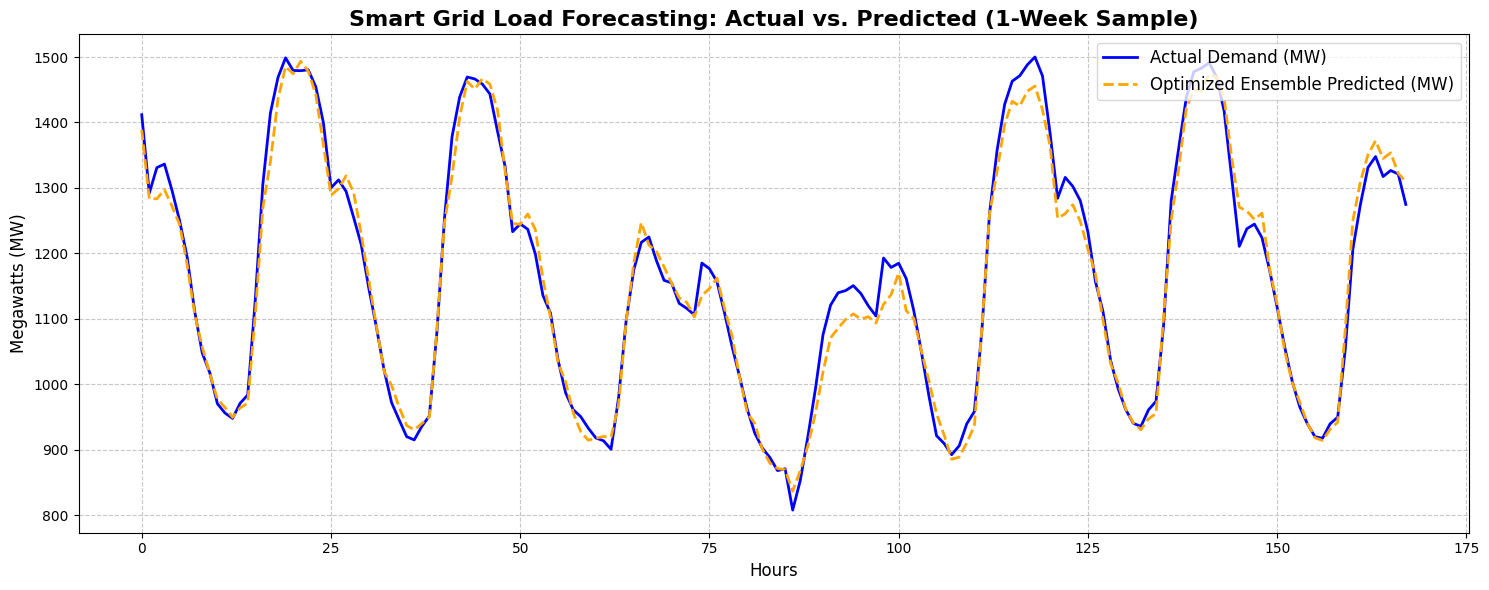

Visualization saved successfully!
Models and Scalers saved successfully!


In [14]:
import matplotlib.pyplot as plt
import joblib
import os

# Create directories to save our outputs if they don't exist
os.makedirs('saved_models', exist_ok=True)
os.makedirs('visualizations', exist_ok=True)

# ---------------------------------------------------------
# 1. GENERATE THE RESULTS CHART
# ---------------------------------------------------------
# We will plot just one week (168 hours) of the test set so it's easy to read
hours_to_plot = 168

plt.figure(figsize=(15, 6))
plt.plot(y_test_actual[:hours_to_plot], label='Actual Demand (MW)', color='blue', linewidth=2)
plt.plot(best_hybrid_preds_mw[:hours_to_plot], label='Optimized Ensemble Predicted (MW)', color='orange', linestyle='dashed', linewidth=2)

plt.title('Smart Grid Load Forecasting: Actual vs. Predicted (1-Week Sample)', fontsize=16, fontweight='bold')
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Megawatts (MW)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the plot as a high-res image for your GitHub README
plt.savefig('visualizations/actual_vs_predicted.png', dpi=300)
plt.show()
print("Visualization saved successfully!")

# ---------------------------------------------------------
# 2. SAVE THE MODELS & SCALERS
# ---------------------------------------------------------
# Save the winning XGBoost model
model_xgb_standalone.save_model('saved_models/xgboost_forecasting_model.json')

# Save the Min-Max Scalers so future data can be scaled the exact same way
joblib.dump(scaler_X, 'saved_models/scaler_X.pkl')
joblib.dump(scaler_y, 'saved_models/scaler_y.pkl')
print("Models and Scalers saved successfully!")

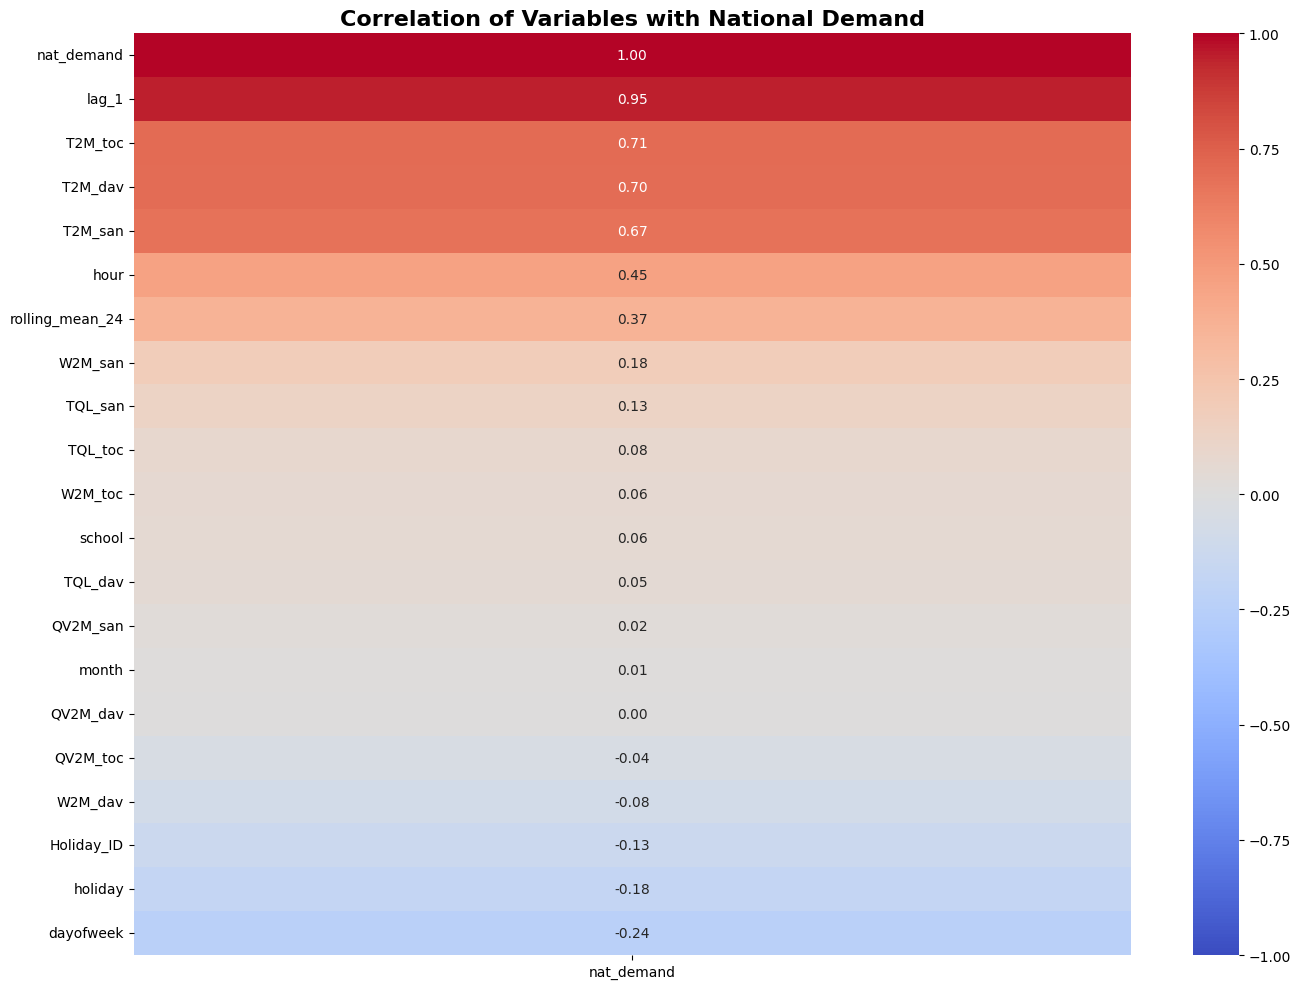

<Figure size 1200x800 with 0 Axes>

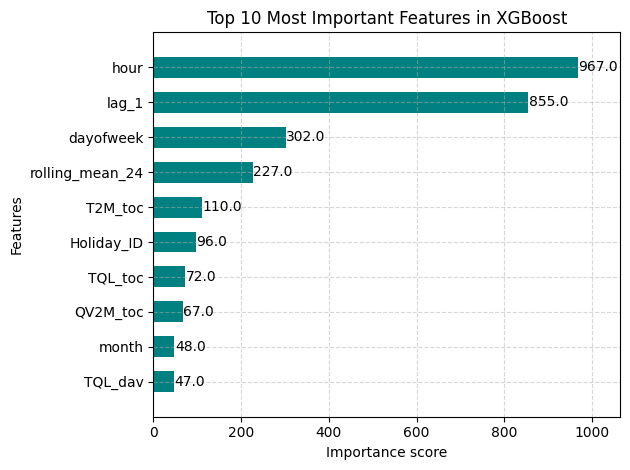

New visualization charts saved successfully!


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import plot_importance

# ---------------------------------------------------------
# 1. GENERATE CORRELATION HEATMAP (For EDA Section)
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))
# Calculate the correlation of all variables with the target, sorted
corr_matrix = df.corr()
target_corr = corr_matrix[['nat_demand']].sort_values(by='nat_demand', ascending=False)

sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation of Variables with National Demand', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap.png', dpi=300)
plt.show()

# ---------------------------------------------------------
# 2. GENERATE XGBOOST FEATURE IMPORTANCE (For Results Section)
# ---------------------------------------------------------
# We need to map the feature names back to the XGBoost model
feature_names = X.columns.tolist()
model_xgb_standalone.get_booster().feature_names = feature_names

plt.figure(figsize=(12, 8))
# Plot the top 10 most important features
plot_importance(model_xgb_standalone, max_num_features=10, importance_type='weight',
                height=0.6, color='teal', title='Top 10 Most Important Features in XGBoost')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('visualizations/feature_importance.png', dpi=300)
plt.show()

print("New visualization charts saved successfully!")